# 🏥 Healthcare Insurance Fraud Detection — Master Notebook
### End-to-End Analytics: Data Understanding → Cleaning → EDA → Fraud Analytics → Feature Engineering

> **Dataset:** `patients.csv` (50K) · `providers.csv` (5K) · `claims.csv` (200K) · `payments.csv` (150K)  
> **Goal:** Build analytics-ready datasets and rule-based fraud intelligence before any ML model.

---
## 📋 Table of Contents
1. [Setup & Imports](#1)
2. [Schema Analysis & Data Quality](#2)
3. [Data Cleaning](#3)
4. [Master Table — Merge All CSVs](#4)
5. [EDA — Patient Analytics](#5)
6. [EDA — Provider Analytics](#6)
7. [EDA — Payment Analytics](#7)
8. [Fraud Discovery Analytics (Rule-Based)](#8)
9. [Feature Engineering](#9)
10. [Risk Score Generation](#10)
11. [Export Final Datasets](#11)


---
## 1. Setup & Imports <a id='1'></a>

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Visual style ──────────────────────────────
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "figure.dpi": 100,
})

print("✅ Libraries loaded successfully.")


✅ Libraries loaded successfully.


In [75]:
# ── Load raw CSVs ─────────────────────────────
patients_raw  = pd.read_csv("..\\data\patients.csv")
providers_raw = pd.read_csv("..\\data\providers.csv")
claims_raw    = pd.read_csv("..\\data\claims.csv")
payments_raw  = pd.read_csv("..\\data\payments.csv")

print("patients.csv  :", patients_raw.shape)
print("providers.csv :", providers_raw.shape)
print("claims.csv    :", claims_raw.shape)
print("payments.csv  :", payments_raw.shape)


patients.csv  : (50000, 10)
providers.csv : (5000, 7)
claims.csv    : (200000, 6)
payments.csv  : (150000, 9)


---
## 2. Schema Analysis & Data Quality <a id='2'></a>

We inspect every column for:
- **dtype** — does it match what we expect?
- **null %** — how much data is missing?
- **unique count** — cardinality check
- **duplicate rows** — full-row duplicates


In [76]:
def schema_report(df, name):
    """Generate per-column quality table for a DataFrame."""
    rows = []
    for col in df.columns:
        null_pct  = round(df[col].isna().mean() * 100, 2)
        unique_n  = df[col].nunique(dropna=False)
        sample    = df[col].dropna().iloc[0] if not df[col].dropna().empty else "N/A"
        rows.append({
            "Column"        : col,
            "Dtype"         : str(df[col].dtype),
            "Null %"        : null_pct,
            "Unique Values" : unique_n,
            "Sample Value"  : sample,
        })
    report = pd.DataFrame(rows)
    dup_count = df.duplicated().sum()
    print(f"\n{'='*60}")
    print(f"  📄 {name}  |  {df.shape[0]:,} rows × {df.shape[1]} cols  |  {dup_count:,} duplicate rows")
    print(f"{'='*60}")
    display(report)
    return report

_ = schema_report(patients_raw,  "patients.csv")
_ = schema_report(providers_raw, "providers.csv")
_ = schema_report(claims_raw,    "claims.csv")
_ = schema_report(payments_raw,  "payments.csv")



  📄 patients.csv  |  50,000 rows × 10 cols  |  0 duplicate rows


,Column,Dtype,Null %,Unique Values,Sample Value
0,patient_id,int64,0.0,50000,1
1,first_name,str,0.0,690,Christopher
2,last_name,str,0.0,1000,Browning
3,age,int64,0.0,72,69
4,gender,str,0.0,3,Male
5,address,str,0.0,50000,"81414 Nancy Lights\nWest Danielton, SC 20053"
6,city,str,0.0,25250,West Stevenstad
7,state,str,0.0,50,Alaska
8,zip_code,int64,0.0,39355,32553
9,phone,str,0.0,50000,225-209-0294



  📄 providers.csv  |  5,000 rows × 7 cols  |  0 duplicate rows


,Column,Dtype,Null %,Unique Values,Sample Value
0,provider_id,int64,0.0,5000,1
1,name,str,0.0,4539,Eaton-Gibson
2,specialty,str,0.0,5,Orthopedic
3,city,str,0.0,4256,North John
4,state,str,0.0,50,South Carolina
5,zip_code,int64,0.0,4857,83283
6,phone,str,0.0,5000,1673383132



  📄 claims.csv  |  200,000 rows × 6 cols  |  0 duplicate rows


,Column,Dtype,Null %,Unique Values,Sample Value
0,claim_id,float64,0.0,200000,1.0
1,patient_id,float64,0.0,49096,23406.0
2,provider_id,float64,0.0,5000,4385.0
3,claim_date,str,0.0,731,2024-01-06
4,claim_amount,float64,0.0,50935,27537.0
5,status,str,0.0,3,Rejected



  📄 payments.csv  |  150,000 rows × 9 cols  |  0 duplicate rows


,Column,Dtype,Null %,Unique Values,Sample Value
0,claim_id,int64,0.0,150000,168783
1,patient_id,int64,0.0,47541,19362
2,provider_id,int64,0.0,5000,1841
3,claim_date,str,0.0,731,2023-04-16
4,claim_amount,int64,0.0,47430,42802
5,status,str,0.0,3,Approved
6,payment_id,int64,0.0,150000,1
7,payment_date,str,0.0,731,2024-10-24
8,payment_amount,float64,0.0,150000,37786.693267


In [77]:
# ── Targeted quality checks ───────────────────

print("=== PATIENTS — Quality Checks ===")
print(f"  Age < 0  : {(patients_raw['age'] < 0).sum()}")
print(f"  Age > 100: {(patients_raw['age'] > 100).sum()}")
print(f"  Gender values: {patients_raw['gender'].unique()}")
print(f"  Duplicate patient_id: {patients_raw['patient_id'].duplicated().sum()}")

print("\n=== PROVIDERS — Quality Checks ===")
print(f"  Duplicate provider_id: {providers_raw['provider_id'].duplicated().sum()}")
print(f"  Missing specialty: {providers_raw['specialty'].isna().sum()}")
print(f"  Unique specialties ({providers_raw['specialty'].nunique()}): {providers_raw['specialty'].unique()[:10]}")

print("\n=== CLAIMS — Quality Checks ===")
print(f"  Duplicate claim_id: {claims_raw['claim_id'].duplicated().sum()}")
print(f"  Negative claim_amount: {(claims_raw['claim_amount'] < 0).sum()}")
print(f"  Null claim_id: {claims_raw['claim_id'].isna().sum()}")
print(f"  Status values: {claims_raw['status'].unique()}")

print("\n=== PAYMENTS — Quality Checks ===")
print(f"  Duplicate payment_id: {payments_raw['payment_id'].duplicated().sum()}")
print(f"  payment > claim_amount: {(payments_raw['payment_amount'] > payments_raw['claim_amount']).sum()}")
print(f"  Missing payment_amount: {payments_raw['payment_amount'].isna().sum()}")


=== PATIENTS — Quality Checks ===
  Age < 0  : 0
  Age > 100: 0
  Gender values: <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
  Duplicate patient_id: 0

=== PROVIDERS — Quality Checks ===
  Duplicate provider_id: 0
  Missing specialty: 0
  Unique specialties (5): <StringArray>
[          'Orthopedic', 'General Practitioner',        'Dermatologist',
         'Cardiologist',           'Oncologist']
Length: 5, dtype: str

=== CLAIMS — Quality Checks ===
  Duplicate claim_id: 0
  Negative claim_amount: 0
  Null claim_id: 0
  Status values: <StringArray>
['Rejected', 'Approved', 'Pending']
Length: 3, dtype: str

=== PAYMENTS — Quality Checks ===
  Duplicate payment_id: 0
  payment > claim_amount: 0
  Missing payment_amount: 0


---
## 3. Data Cleaning <a id='3'></a>

Steps for each table:
- Fix dtypes (especially dates and IDs)
- Drop full-row duplicates
- Cap / flag invalid values
- Standardise text columns


In [78]:
# ── PATIENTS ──────────────────────────────────
patients = patients_raw.copy()

# Drop full-row duplicates
patients.drop_duplicates(inplace=True)

# Age guardrails
patients['age'] = patients['age'].clip(lower=0, upper=120)

# Standardise gender
patients['gender'] = patients['gender'].str.strip().str.title()

# Standardise state
patients['state'] = patients['state'].str.strip().str.title()

print(f"✅ patients cleaned: {patients.shape}")
patients.head(3)


✅ patients cleaned: (50000, 10)


,patient_id,first_name,last_name,age,gender,address,city,state,zip_code,phone
0,1,Christopher,Browning,69,Male,"81414 Nancy Lights\nWest Danielton, SC 20053",West Stevenstad,Alaska,32553,225-209-0294
1,2,Jessica,House,32,Female,"87699 Carl Prairie\nEast Gary, IN 50313",Cobbton,South Dakota,45348,197-404-2321x531
2,3,Molly,Weaver,89,Female,"805 Bolton Terrace\nNew Ryan, VA 38491",South Toddland,South Dakota,99561,093-339-5088x52109


In [79]:
# ── PROVIDERS ─────────────────────────────────
providers = providers_raw.copy()

providers.drop_duplicates(inplace=True)
providers['specialty'] = providers['specialty'].str.strip().str.title()
providers['state']     = providers['state'].str.strip().str.title()

print(f"✅ providers cleaned: {providers.shape}")
providers.head(3)


✅ providers cleaned: (5000, 7)


,provider_id,name,specialty,city,state,zip_code,phone
0,1,Eaton-Gibson,Orthopedic,North John,South Carolina,83283,1673383132
1,2,Lewis Ltd,General Practitioner,South Joshuahaven,Connecticut,14837,+1-714-989-1321x074
2,3,Wise Ltd,Dermatologist,New Oliviaside,Vermont,85931,(690)540-7413x281


In [80]:
# ── CLAIMS ────────────────────────────────────
claims = claims_raw.copy()

# Fix dtypes
claims['claim_id']    = claims['claim_id'].astype('Int64')
claims['patient_id']  = claims['patient_id'].astype('Int64')
claims['provider_id'] = claims['provider_id'].astype('Int64')
claims['claim_date']  = pd.to_datetime(claims['claim_date'], errors='coerce')
claims['claim_amount']= claims['claim_amount'].clip(lower=0)

# Drop rows with null PKs
claims.dropna(subset=['claim_id', 'patient_id', 'provider_id'], inplace=True)
claims.drop_duplicates(inplace=True)

# Standardise status
claims['status'] = claims['status'].str.strip().str.title()

print(f"✅ claims cleaned: {claims.shape}")
claims.head(3)


✅ claims cleaned: (200000, 6)


,claim_id,patient_id,provider_id,claim_date,claim_amount,status
0,1,23406,4385,2024-01-06,27537.0,Rejected
1,2,21811,4979,2024-01-27,40137.0,Approved
2,3,13518,242,2024-04-03,20860.0,Approved


In [81]:
# ── PAYMENTS ──────────────────────────────────
payments = payments_raw.copy()

payments['claim_date']    = pd.to_datetime(payments['claim_date'], errors='coerce')
payments['payment_date']  = pd.to_datetime(payments['payment_date'], errors='coerce')
payments['payment_amount']= payments['payment_amount'].clip(lower=0)
payments['status']        = payments['status'].str.strip().str.title()

payments.drop_duplicates(inplace=True)

print(f"✅ payments cleaned: {payments.shape}")
payments.head(3)


✅ payments cleaned: (150000, 9)


,claim_id,patient_id,provider_id,claim_date,claim_amount,status,payment_id,payment_date,payment_amount
0,168783,19362,1841,2023-04-16,42802,Approved,1,2024-10-24,37786.693267
1,62739,11468,2047,2023-05-14,12319,Approved,2,2023-09-06,12150.993936
2,109834,31427,2620,2024-12-28,756,Approved,3,2023-03-10,687.131418


---
## 4. Master Table — Merge All CSVs <a id='4'></a>

**Merge strategy:**
```
claims
  LEFT JOIN patients   ON patient_id
  LEFT JOIN providers  ON provider_id
  LEFT JOIN payments   ON claim_id
```
This is our single analytics layer — `master_df`.


In [82]:
# ── Build master_df ───────────────────────────

master_df = (
    claims
    .merge(patients[['patient_id','age','gender','state']].rename(columns={'state':'patient_state'}),
           on='patient_id', how='left')
    .merge(providers[['provider_id','name','specialty','state']].rename(columns={
               'name':'provider_name', 'state':'provider_state'}),
           on='provider_id', how='left')
    .merge(payments[['claim_id','payment_id','payment_date','payment_amount']],
           on='claim_id', how='left')
)

# Settlement delay (days)
master_df['settlement_days'] = (master_df['payment_date'] - master_df['claim_date']).dt.days

# Payment ratio
master_df['payment_ratio'] = (
    master_df['payment_amount'] / master_df['claim_amount'].replace(0, np.nan)
).round(4)

print(f"master_df shape: {master_df.shape}")
print(f"Columns: {list(master_df.columns)}")
master_df.head(3)


master_df shape: (200000, 17)
Columns: ['claim_id', 'patient_id', 'provider_id', 'claim_date', 'claim_amount', 'status', 'age', 'gender', 'patient_state', 'provider_name', 'specialty', 'provider_state', 'payment_id', 'payment_date', 'payment_amount', 'settlement_days', 'payment_ratio']


,claim_id,patient_id,provider_id,claim_date,claim_amount,status,age,gender,patient_state,provider_name,specialty,provider_state,payment_id,payment_date,payment_amount,settlement_days,payment_ratio
0,1,23406,4385,2024-01-06,27537.0,Rejected,67,Other,South Dakota,Campos-Howe,General Practitioner,Idaho,97484.0,2023-06-07,26289.122224,-213.0,0.9547
1,2,21811,4979,2024-01-27,40137.0,Approved,24,Female,Nebraska,Reese LLC,Oncologist,Kansas,132961.0,2024-03-22,39423.897457,55.0,0.9822
2,3,13518,242,2024-04-03,20860.0,Approved,83,Male,Hawaii,Russo LLC,Oncologist,Maryland,139181.0,2024-10-11,17859.308671,191.0,0.8562


In [83]:
# Quick null audit on master_df
null_pct = (master_df.isna().mean() * 100).round(2).sort_values(ascending=False)
print("Null % per column in master_df:")
print(null_pct[null_pct > 0].to_string())


Null % per column in master_df:
payment_date       25.0
payment_id         25.0
payment_amount     25.0
settlement_days    25.0
payment_ratio      25.0


---
## 5. EDA — Patient Analytics <a id='5'></a>


In [84]:
# ── KPIs ──────────────────────────────────────
total_patients   = patients['patient_id'].nunique()
avg_age          = patients['age'].mean()
gender_ratio     = patients['gender'].value_counts(normalize=True).mul(100).round(1)
claims_per_pat   = master_df.groupby('patient_id')['claim_id'].count()

print(f"Total Unique Patients  : {total_patients:,}")
print(f"Average Patient Age    : {avg_age:.1f} years")
print(f"\nGender Distribution:")
print(gender_ratio.to_string())
print(f"\nClaims per Patient  — Mean: {claims_per_pat.mean():.2f}  |  Max: {claims_per_pat.max()}")


Total Unique Patients  : 50,000
Average Patient Age    : 53.4 years

Gender Distribution:
gender
Male      47.9
Female    47.9
Other      4.1

Claims per Patient  — Mean: 4.07  |  Max: 15


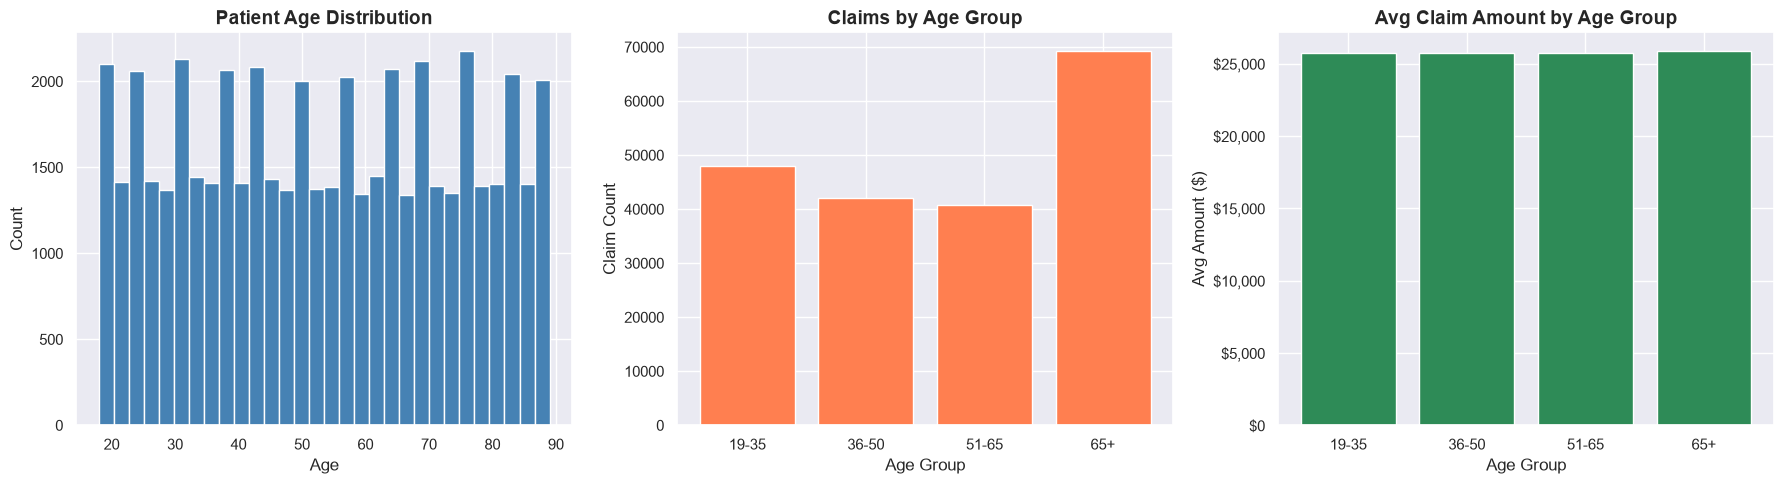

age_group  claim_count
    19-35        48019
    36-50        41982
    51-65        40765
      65+        69234


In [85]:
# ── Age Group Analysis ────────────────────────
bins   = [0, 18, 35, 50, 65, 120]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']
master_df['age_group'] = pd.cut(master_df['age'], bins=bins, labels=labels, right=False)

age_claims = (
    master_df.groupby('age_group', observed=True)['claim_id']
    .count().reset_index()
    .rename(columns={'claim_id': 'claim_count'})
)
age_amount = (
    master_df.groupby('age_group', observed=True)['claim_amount']
    .mean().reset_index()
    .rename(columns={'claim_amount': 'avg_claim_amount'})
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution
axes[0].hist(patients['age'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title("Patient Age Distribution")
axes[0].set_xlabel("Age"); axes[0].set_ylabel("Count")

# Claims by age group
axes[1].bar(age_claims['age_group'].astype(str), age_claims['claim_count'],
            color='coral', edgecolor='white')
axes[1].set_title("Claims by Age Group")
axes[1].set_xlabel("Age Group"); axes[1].set_ylabel("Claim Count")

# Avg claim by age group
axes[2].bar(age_amount['age_group'].astype(str), age_amount['avg_claim_amount'],
            color='seagreen', edgecolor='white')
axes[2].set_title("Avg Claim Amount by Age Group")
axes[2].set_xlabel("Age Group"); axes[2].set_ylabel("Avg Amount ($)")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig("..\\image\patient_age_analysis.png", dpi=100, bbox_inches='tight')
plt.show()
print(age_claims.to_string(index=False))


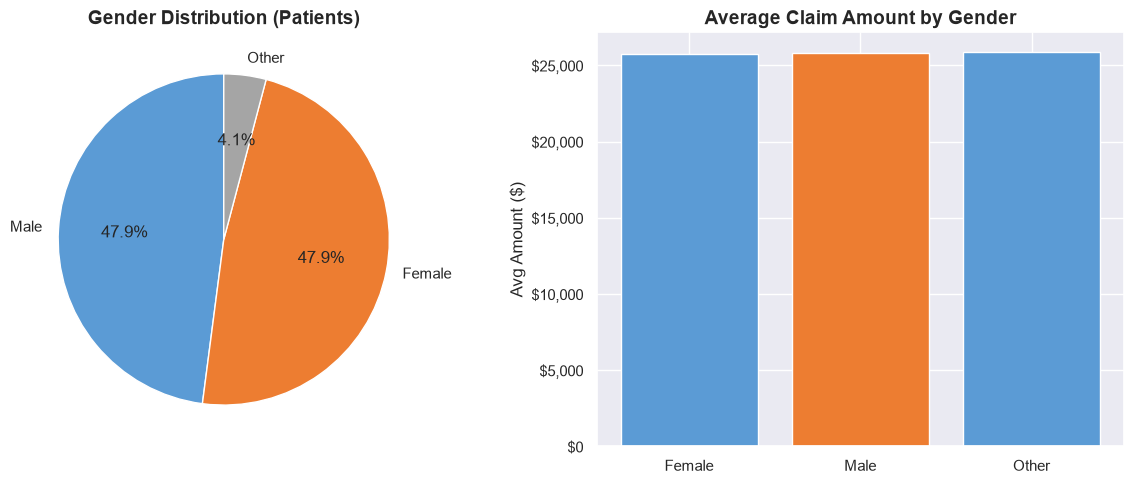

gender  claim_count    avg_claim
Female        96173 25753.249839
  Male        95647 25827.591678
 Other         8180 25869.497793


In [86]:
# ── Gender analysis ───────────────────────────
gender_claims = (
    master_df.groupby('gender')
    .agg(claim_count=('claim_id','count'), avg_claim=('claim_amount','mean'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    patients['gender'].value_counts(),
    labels=patients['gender'].value_counts().index,
    autopct='%1.1f%%', startangle=90,
    colors=['#5B9BD5','#ED7D31','#A5A5A5']
)
axes[0].set_title("Gender Distribution (Patients)")

axes[1].bar(gender_claims['gender'], gender_claims['avg_claim'],
            color=['#5B9BD5','#ED7D31'], edgecolor='white')
axes[1].set_title("Average Claim Amount by Gender")
axes[1].set_ylabel("Avg Amount ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig("..\\image\patient_gender_analysis.png", dpi=100, bbox_inches='tight')
plt.show()
print(gender_claims.to_string(index=False))


---
## 6. EDA — Provider Analytics <a id='6'></a>

> ⚠️ **This is where fraud signals begin.** Providers with unusually high claim counts or amounts warrant deeper investigation.


In [87]:
# ── Provider KPIs ─────────────────────────────
provider_stats = (
    master_df.groupby(['provider_id','provider_name','specialty'])
    .agg(
        claim_count   = ('claim_id',   'count'),
        total_revenue = ('claim_amount','sum'),
        avg_claim     = ('claim_amount','mean'),
        rejection_count = ('status', lambda x: (x == 'Rejected').sum()),
    )
    .reset_index()
)
provider_stats['rejection_rate'] = (
    provider_stats['rejection_count'] / provider_stats['claim_count']
).round(4)

print(f"Providers in dataset   : {provider_stats['provider_id'].nunique():,}")
print(f"\nTop stats:")
print(f"  Max claims by one provider : {provider_stats['claim_count'].max():,}")
print(f"  Avg claims per provider    : {provider_stats['claim_count'].mean():.1f}")
print(f"  Max total revenue          : ${provider_stats['total_revenue'].max():,.0f}")


Providers in dataset   : 5,000

Top stats:
  Max claims by one provider : 64
  Avg claims per provider    : 40.0
  Max total revenue          : $1,809,033


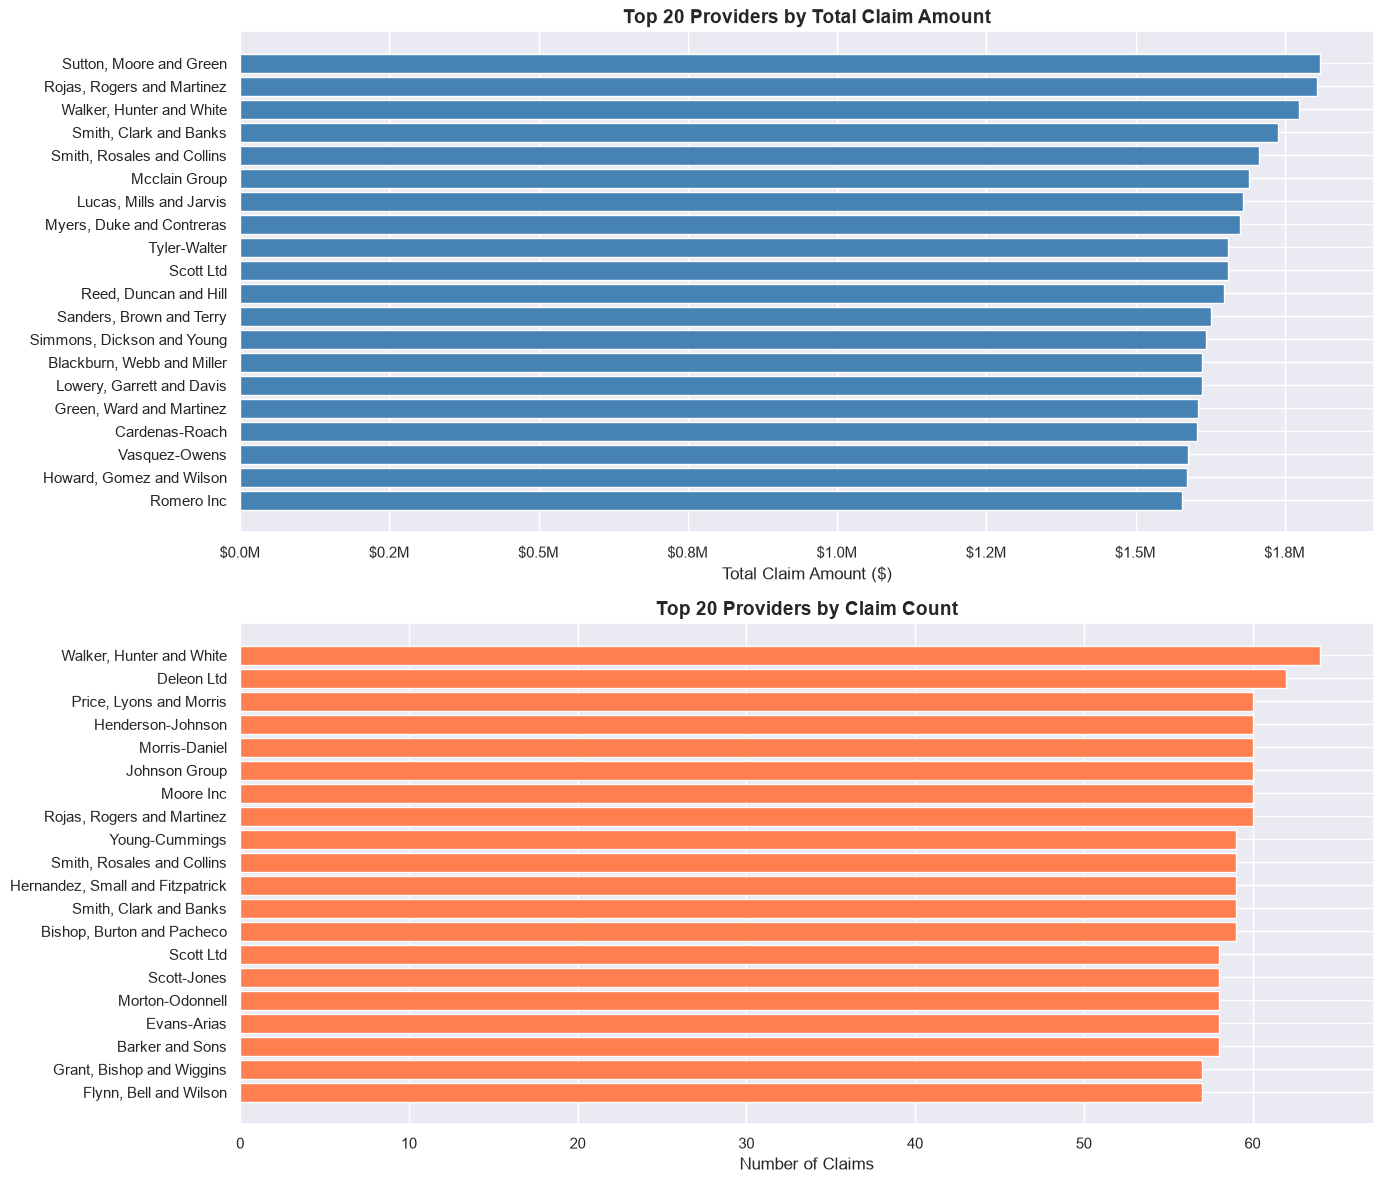

In [88]:
# ── Top 20 Providers by Claim Amount ──────────
top20_amount = provider_stats.nlargest(20, 'total_revenue')

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# By total revenue
axes[0].barh(top20_amount['provider_name'], top20_amount['total_revenue'],
             color='steelblue', edgecolor='white')
axes[0].set_title("Top 20 Providers by Total Claim Amount")
axes[0].set_xlabel("Total Claim Amount ($)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
axes[0].invert_yaxis()

# By claim count
top20_count = provider_stats.nlargest(20, 'claim_count')
axes[1].barh(top20_count['provider_name'], top20_count['claim_count'],
             color='coral', edgecolor='white')
axes[1].set_title("Top 20 Providers by Claim Count")
axes[1].set_xlabel("Number of Claims")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("..\\image\provider_top20.png", dpi=100, bbox_inches='tight')
plt.show()


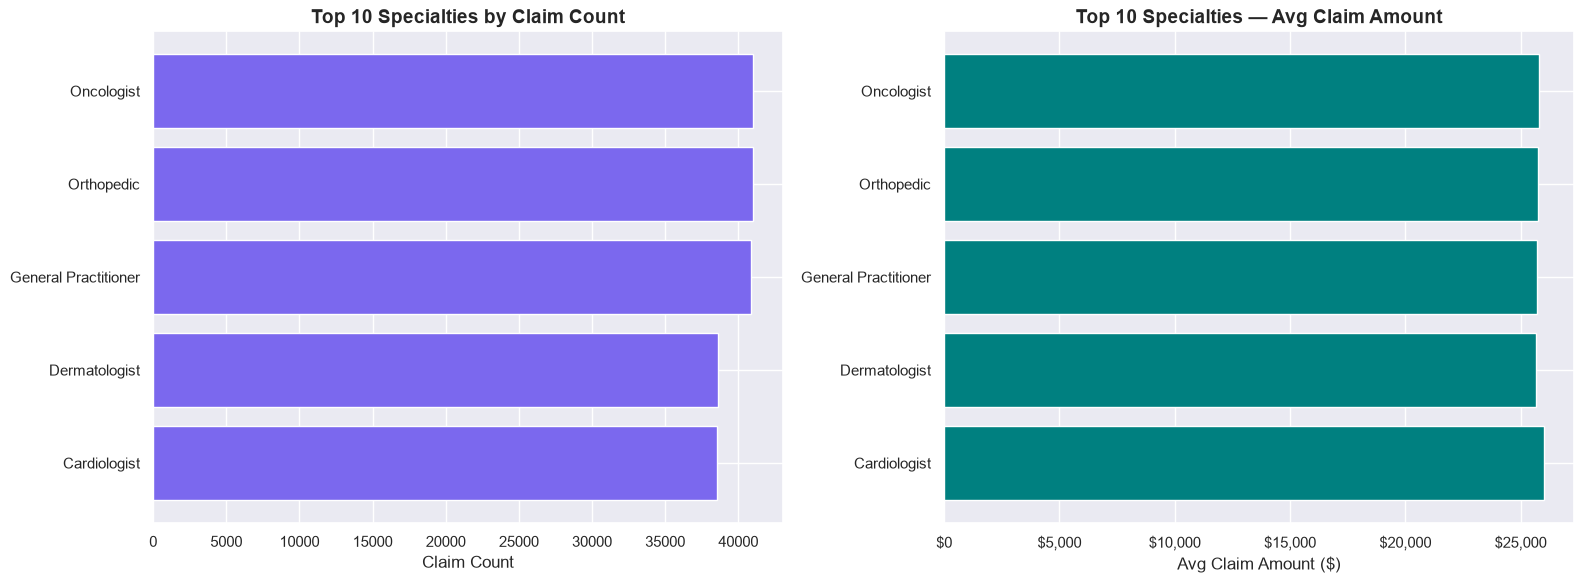

           specialty  claim_count    avg_claim  total_amount
          Oncologist        41004 25802.000882  1.057985e+09
          Orthopedic        40989 25764.389712  1.056057e+09
General Practitioner        40849 25722.534270  1.050740e+09
       Dermatologist        38606 25674.761146  9.911998e+08
        Cardiologist        38552 26009.805059  1.002730e+09


In [89]:
# ── Specialty-wise Claim Distribution ─────────
specialty_stats = (
    master_df.groupby('specialty')
    .agg(
        claim_count = ('claim_id',   'count'),
        avg_claim   = ('claim_amount','mean'),
        total_amount= ('claim_amount','sum'),
    )
    .reset_index()
    .sort_values('claim_count', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_specs = specialty_stats.head(10)
axes[0].barh(top_specs['specialty'], top_specs['claim_count'],
             color='mediumslateblue', edgecolor='white')
axes[0].set_title("Top 10 Specialties by Claim Count")
axes[0].set_xlabel("Claim Count")
axes[0].invert_yaxis()

axes[1].barh(top_specs['specialty'], top_specs['avg_claim'],
             color='teal', edgecolor='white')
axes[1].set_title("Top 10 Specialties — Avg Claim Amount")
axes[1].set_xlabel("Avg Claim Amount ($)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("..\\image\specialty_analysis.png", dpi=100, bbox_inches='tight')
plt.show()
print(specialty_stats.to_string(index=False))


---
## 7. EDA — Payment Analytics <a id='7'></a>


=== Claim vs Payment Gap ($) ===
count    $150,000.00
mean       $3,214.26
std        $8,598.68
min            $0.01
25%          $696.51
50%        $1,925.30
75%        $3,937.02
max      $207,279.73


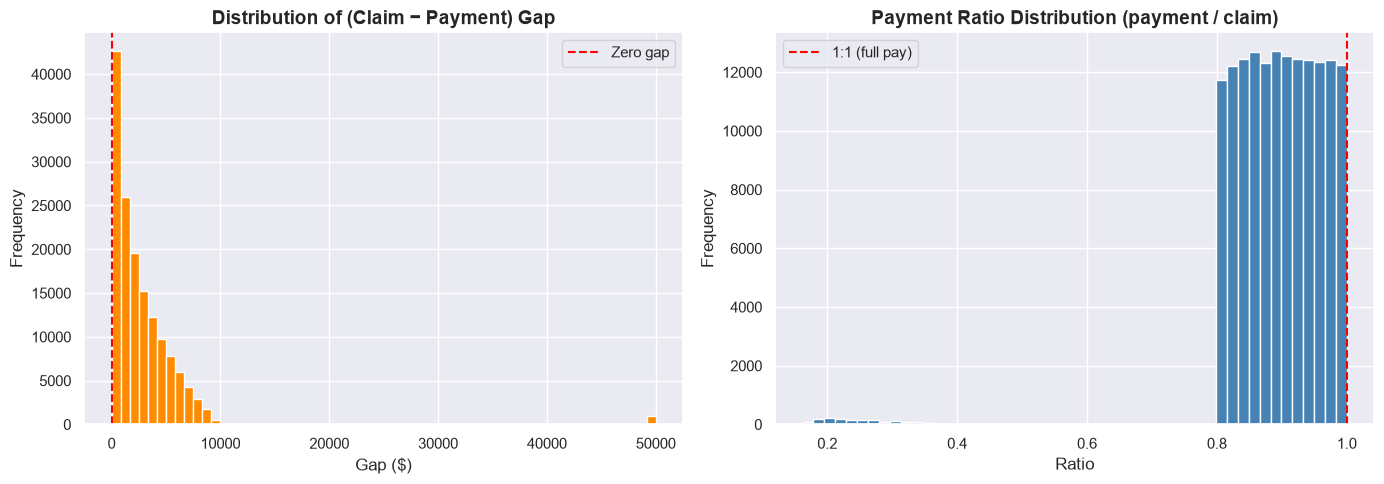

In [90]:
# ── Claim vs Payment gap ──────────────────────
paid_df = master_df.dropna(subset=['payment_amount']).copy()
paid_df['gap'] = paid_df['claim_amount'] - paid_df['payment_amount']

print("=== Claim vs Payment Gap ($) ===")
print(paid_df['gap'].describe().apply(lambda x: f"${x:,.2f}").to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(paid_df['gap'].clip(-5000, 50000), bins=60,
             color='darkorange', edgecolor='white')
axes[0].set_title("Distribution of (Claim − Payment) Gap")
axes[0].set_xlabel("Gap ($)"); axes[0].set_ylabel("Frequency")
axes[0].axvline(0, color='red', linestyle='--', label='Zero gap')
axes[0].legend()

axes[1].hist(paid_df['payment_ratio'].clip(0, 2), bins=50,
             color='steelblue', edgecolor='white')
axes[1].set_title("Payment Ratio Distribution (payment / claim)")
axes[1].set_xlabel("Ratio"); axes[1].set_ylabel("Frequency")
axes[1].axvline(1.0, color='red', linestyle='--', label='1:1 (full pay)')
axes[1].legend()

plt.tight_layout()
plt.savefig("..\\image\payment_gap_analysis.png", dpi=100, bbox_inches='tight')
plt.show()


=== Settlement Delay (days) ===
count    150000.0 days
mean          0.7 days
std         298.7 days
min        -729.0 days
25%        -215.0 days
50%           0.0 days
75%         216.0 days
max         730.0 days


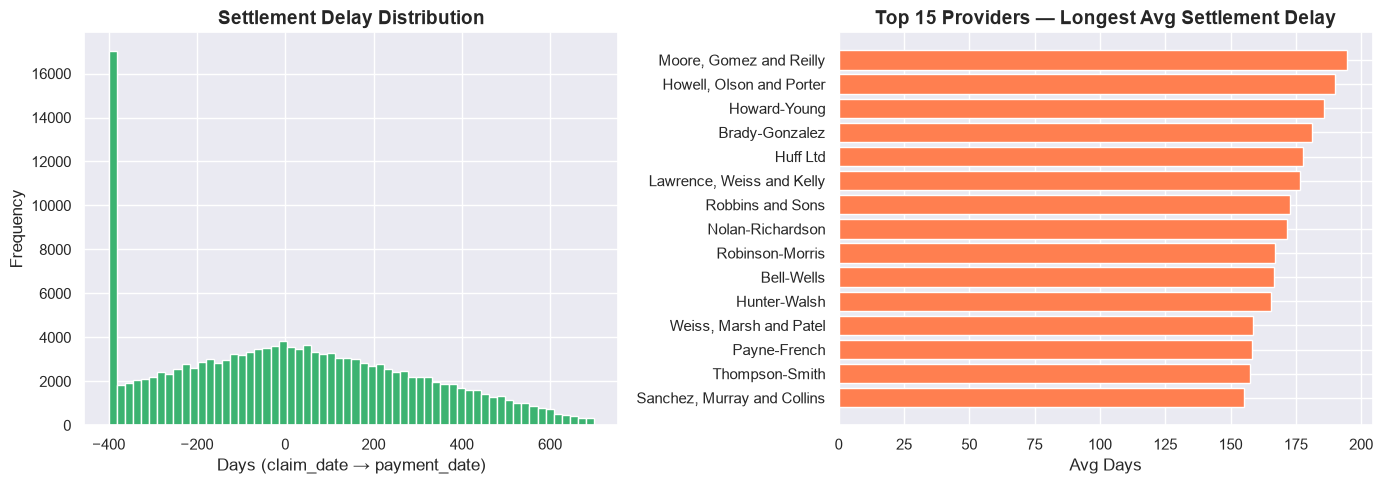

In [91]:
# ── Settlement delay analysis ─────────────────
delay_df = master_df.dropna(subset=['settlement_days']).copy()

print("=== Settlement Delay (days) ===")
print(delay_df['settlement_days'].describe().apply(lambda x: f"{x:.1f} days").to_string())

# Providers with highest avg settlement delay
delay_by_provider = (
    delay_df.groupby('provider_name')['settlement_days']
    .mean().reset_index()
    .sort_values('settlement_days', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(delay_df['settlement_days'].clip(-400, 700), bins=60,
             color='mediumseagreen', edgecolor='white')
axes[0].set_title("Settlement Delay Distribution")
axes[0].set_xlabel("Days (claim_date → payment_date)")
axes[0].set_ylabel("Frequency")

axes[1].barh(delay_by_provider['provider_name'],
             delay_by_provider['settlement_days'],
             color='coral', edgecolor='white')
axes[1].set_title("Top 15 Providers — Longest Avg Settlement Delay")
axes[1].set_xlabel("Avg Days")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("..\\image\settlement_delay.png", dpi=100, bbox_inches='tight')
plt.show()


---
## 8. Fraud Discovery Analytics — Rule-Based <a id='8'></a>

We identify fraud *before* ML by encoding domain rules.

| Rule | Name | Description |
|------|------|-------------|
| FR-1 | Duplicate Claims | Same patient + provider + date + amount |
| FR-2 | Excessive Billing | Provider avg claim > 3σ above specialty mean |
| FR-3 | Abnormal Claim Frequency | Provider claim count ≫ specialty average |
| FR-4 | Patient Shopping | Patient visits many providers in short window |
| FR-5 | High Rejection Rate | Provider rejection rate >> specialty median |


In [92]:
# ── FR-1: Duplicate Claims ────────────────────
dup_cols = ['patient_id', 'provider_id', 'claim_date', 'claim_amount']
dup_mask = master_df.duplicated(subset=dup_cols, keep=False)
dup_claims = master_df[dup_mask].copy()
dup_claims['fraud_flag_FR1'] = 1

print(f"FR-1 | Duplicate Claims Detected : {dup_mask.sum():,} rows")
print(f"      Unique duplicate groups    : {dup_claims.groupby(dup_cols).ngroups:,}")
print("\nSample duplicate claims:")
display(dup_claims[dup_cols + ['claim_id','status']].head(6))


FR-1 | Duplicate Claims Detected : 0 rows
      Unique duplicate groups    : 0

Sample duplicate claims:


,patient_id,provider_id,claim_date,claim_amount,claim_id,status


In [93]:
# ── FR-2: Excessive Billing (provider avg > μ + 3σ by specialty) ─
specialty_stats_billing = (
    master_df.groupby('specialty')['claim_amount']
    .agg(['mean','std'])
    .reset_index()
    .rename(columns={'mean':'spec_mean_claim','std':'spec_std_claim'})
)
specialty_stats_billing['upper_3sigma'] = (
    specialty_stats_billing['spec_mean_claim'] +
    3 * specialty_stats_billing['spec_std_claim'].fillna(0)
)

provider_avg = (
    master_df.groupby(['provider_id','provider_name','specialty'])['claim_amount']
    .mean().reset_index().rename(columns={'claim_amount':'provider_avg_claim'})
)

provider_billing = provider_avg.merge(specialty_stats_billing, on='specialty')
provider_billing['fraud_flag_FR2'] = (
    provider_billing['provider_avg_claim'] > provider_billing['upper_3sigma']
).astype(int)

flagged_fr2 = provider_billing[provider_billing['fraud_flag_FR2'] == 1]
print(f"FR-2 | Excessive Billing Providers : {len(flagged_fr2):,}")
print(f"      (avg claim > specialty μ + 3σ)")
display(flagged_fr2[['provider_name','specialty','provider_avg_claim','upper_3sigma']].head(10))


FR-2 | Excessive Billing Providers : 0
      (avg claim > specialty μ + 3σ)


,provider_name,specialty,provider_avg_claim,upper_3sigma


In [94]:
# ── FR-3: Abnormal Claim Frequency ───────────
specialty_freq = (
    master_df.groupby(['provider_id','specialty'])['claim_id']
    .count().reset_index().rename(columns={'claim_id':'provider_claim_count'})
)
spec_mean_freq = (
    specialty_freq.groupby('specialty')['provider_claim_count']
    .agg(['mean','std']).reset_index()
    .rename(columns={'mean':'spec_mean_freq','std':'spec_std_freq'})
)
specialty_freq = specialty_freq.merge(spec_mean_freq, on='specialty')
specialty_freq['upper_freq_3sigma'] = (
    specialty_freq['spec_mean_freq'] +
    3 * specialty_freq['spec_std_freq'].fillna(0)
)
specialty_freq['fraud_flag_FR3'] = (
    specialty_freq['provider_claim_count'] > specialty_freq['upper_freq_3sigma']
).astype(int)

flagged_fr3 = specialty_freq[specialty_freq['fraud_flag_FR3'] == 1]
print(f"FR-3 | Abnormal Claim Frequency Providers : {len(flagged_fr3):,}")
display(flagged_fr3[['provider_id','specialty','provider_claim_count','spec_mean_freq']].head(10))


FR-3 | Abnormal Claim Frequency Providers : 11


,provider_id,specialty,provider_claim_count,spec_mean_freq
368,369,Dermatologist,60,39.923475
772,773,Cardiologist,59,40.200209
1422,1423,Orthopedic,64,40.343504
1703,1704,Oncologist,59,39.925998
2280,2281,Oncologist,60,39.925998
2781,2782,Orthopedic,60,40.343504
3347,3348,Dermatologist,60,39.923475
3450,3451,Cardiologist,60,40.200209
4178,4179,Cardiologist,59,40.200209
4194,4195,Oncologist,60,39.925998


In [95]:
# ── FR-4: Patient Shopping (many providers in 60-day window) ─────
# For efficiency, use a simple aggregate: patients with top-decile provider diversity
patient_provider_counts = (
    master_df.groupby('patient_id')['provider_id']
    .nunique().reset_index()
    .rename(columns={'provider_id':'unique_providers'})
)
threshold_shopping = patient_provider_counts['unique_providers'].quantile(0.95)
flagged_fr4 = patient_provider_counts[
    patient_provider_counts['unique_providers'] >= threshold_shopping
]

print(f"FR-4 | Patient Shopping (top 5% by unique providers visited)")
print(f"      Threshold         : {threshold_shopping:.0f}+ providers")
print(f"      Flagged Patients  : {len(flagged_fr4):,}")
print(flagged_fr4['unique_providers'].describe().to_string())


FR-4 | Patient Shopping (top 5% by unique providers visited)
      Threshold         : 8+ providers
      Flagged Patients  : 2,506
count    2506.000000
mean        8.662809
std         0.990186
min         8.000000
25%         8.000000
50%         8.000000
75%         9.000000
max        15.000000


In [96]:
# ── FR-5: High Rejection Rate Providers ──────
spec_rejection = (
    master_df.groupby('specialty')['status']
    .apply(lambda x: (x == 'Rejected').mean())
    .reset_index().rename(columns={'status':'spec_rejection_median'})
)
provider_rejection = (
    master_df.groupby(['provider_id','provider_name','specialty'])
    .apply(lambda x: pd.Series({
        'claim_count'    : len(x),
        'rejection_rate' : (x['status'] == 'Rejected').mean()
    })).reset_index()
)
provider_rejection = provider_rejection.merge(spec_rejection, on='specialty')
provider_rejection['fraud_flag_FR5'] = (
    (provider_rejection['rejection_rate'] > provider_rejection['spec_rejection_median'] * 2)
    & (provider_rejection['claim_count'] >= 20)
).astype(int)

flagged_fr5 = provider_rejection[provider_rejection['fraud_flag_FR5'] == 1]
print(f"FR-5 | High Rejection Rate Providers : {len(flagged_fr5):,}")
display(flagged_fr5[['provider_name','specialty','claim_count',
                      'rejection_rate','spec_rejection_median']].head(10))


FR-5 | High Rejection Rate Providers : 13


,provider_name,specialty,claim_count,rejection_rate,spec_rejection_median
20,"Byrd, Beck and Mendoza",Orthopedic,32.0,0.406250,0.196394
249,Burns-Watson,Dermatologist,43.0,0.418605,0.197949
413,Shelton Ltd,Dermatologist,45.0,0.400000,0.197949
670,Collier-Conrad,Dermatologist,37.0,0.405405,0.197949
1100,Estes LLC,Oncologist,40.0,0.400000,0.198883
1926,"Thompson, Green and Miller",Dermatologist,25.0,0.400000,0.197949
1949,King Group,General Practitioner,37.0,0.432432,0.197875
2252,"Lane, Garcia and Mills",General Practitioner,25.0,0.400000,0.197875
3072,Watts-Guerrero,General Practitioner,40.0,0.400000,0.197875
3292,"White, Arnold and Tanner",Cardiologist,49.0,0.408163,0.195347


OSError: [Errno 22] Invalid argument: '..\\image\x0craud_dashboard.png'

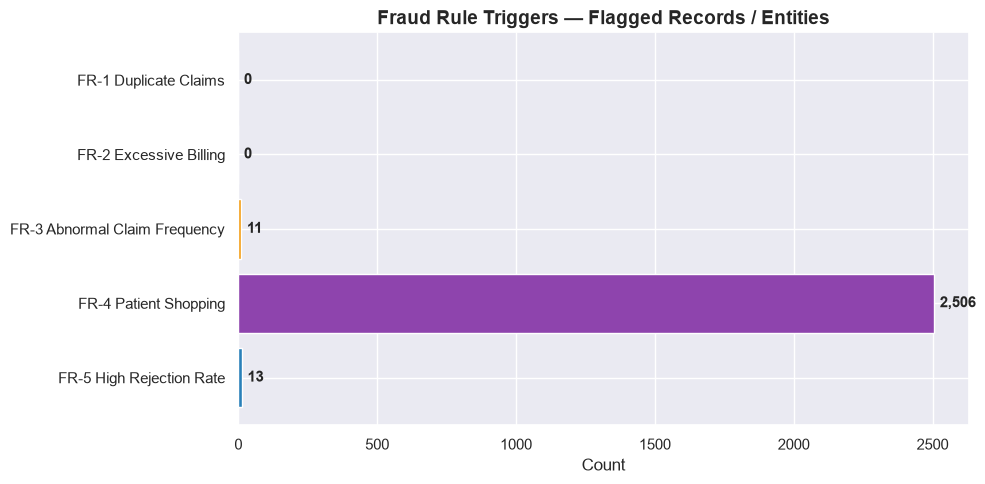

In [97]:
# ── Fraud Summary Dashboard ───────────────────
fraud_flags = {
    'FR-1 Duplicate Claims'          : dup_mask.sum(),
    'FR-2 Excessive Billing'         : len(flagged_fr2),
    'FR-3 Abnormal Claim Frequency'  : len(flagged_fr3),
    'FR-4 Patient Shopping'          : len(flagged_fr4),
    'FR-5 High Rejection Rate'       : len(flagged_fr5),
}

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#E74C3C','#E67E22','#F39C12','#8E44AD','#2980B9']
bars = ax.barh(list(fraud_flags.keys()), list(fraud_flags.values()),
               color=colors, edgecolor='white')
ax.set_title("Fraud Rule Triggers — Flagged Records / Entities", fontsize=14, fontweight='bold')
ax.set_xlabel("Count")
for bar, val in zip(bars, fraud_flags.values()):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=11, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("..\\image\fraud_dashboard.png", dpi=100, bbox_inches='tight')
plt.show()


---
## 9. Feature Engineering <a id='9'></a>

We engineer features across four domains: **Patient · Provider · Payment · Time**.  
These become the input columns for any downstream ML model.


In [ ]:
# ── Patient-level features ────────────────────
patient_feats = (
    master_df.groupby('patient_id')
    .agg(
        claims_per_patient     = ('claim_id',      'count'),
        avg_claim_patient      = ('claim_amount',   'mean'),
        patient_lifetime_value = ('claim_amount',   'sum'),
        last_claim_date        = ('claim_date',     'max'),
        unique_providers_visited = ('provider_id',  'nunique'),
    )
    .reset_index()
)
patient_feats['days_since_last_claim'] = (
    pd.Timestamp('today') - patient_feats['last_claim_date']
).dt.days

# Flag patient shoppers
patient_feats['patient_shopping_flag'] = (
    patient_feats['unique_providers_visited'] >= threshold_shopping
).astype(int)

print("Patient features shape:", patient_feats.shape)
patient_feats.head(3)


Patient features shape: (49096, 8)


,patient_id,claims_per_patient,avg_claim_patient,patient_lifetime_value,last_claim_date,unique_providers_visited,days_since_last_claim,patient_shopping_flag
0,1,2,38034.5,76069.0,2024-07-14,2,705,0
1,2,5,24458.0,122290.0,2024-10-09,5,618,0
2,3,1,39242.0,39242.0,2023-03-29,1,1178,0


In [ ]:
# ── Provider-level features ───────────────────
provider_feats = (
    master_df.groupby('provider_id')
    .agg(
        provider_claim_count   = ('claim_id',      'count'),
        provider_avg_claim     = ('claim_amount',   'mean'),
        provider_total_revenue = ('claim_amount',   'sum'),
        provider_rejection_rate= ('status', lambda x: (x == 'Rejected').mean()),
        provider_unique_patients = ('patient_id',  'nunique'),
    )
    .reset_index()
)

# Specialty average — for specialty risk
specialty_avg_claim = (
    master_df.groupby('specialty')['claim_amount']
    .mean().reset_index().rename(columns={'claim_amount':'specialty_avg_claim'})
)
provider_specialty = master_df[['provider_id','specialty']].drop_duplicates()
provider_feats = (
    provider_feats
    .merge(provider_specialty, on='provider_id', how='left')
    .merge(specialty_avg_claim, on='specialty', how='left')
)
provider_feats['provider_vs_specialty_ratio'] = (
    provider_feats['provider_avg_claim'] /
    provider_feats['specialty_avg_claim'].replace(0, np.nan)
).round(4)

print("Provider features shape:", provider_feats.shape)
provider_feats.head(3)


Provider features shape: (5000, 9)


,provider_id,provider_claim_count,provider_avg_claim,provider_total_revenue,provider_rejection_rate,provider_unique_patients,specialty,specialty_avg_claim,provider_vs_specialty_ratio
0,1,36,31117.680698,1.120237e+06,0.250000,36,Orthopedic,25764.389712,1.2078
1,2,39,24267.384615,9.464280e+05,0.256410,39,General Practitioner,25722.534270,0.9434
2,3,36,23383.777778,8.418160e+05,0.166667,36,Dermatologist,25674.761146,0.9108


In [ ]:
# ── Payment features ──────────────────────────
payment_feats = (
    master_df.dropna(subset=['payment_amount'])
    .assign(
        payment_ratio   = lambda d: d['payment_amount'] / d['claim_amount'].replace(0, np.nan),
        underpayment_flag = lambda d: (d['payment_amount'] < d['claim_amount'] * 0.5).astype(int),
        overpayment_flag  = lambda d: (d['payment_amount'] > d['claim_amount']).astype(int),
    )
    [['claim_id','payment_ratio','settlement_days','underpayment_flag','overpayment_flag']]
)

print("Payment features shape:", payment_feats.shape)
payment_feats.head(3)


Payment features shape: (150000, 5)


,claim_id,payment_ratio,settlement_days,underpayment_flag,overpayment_flag
0,1,0.954684,-213.0,0,0
1,2,0.982233,55.0,0,0
2,3,0.856151,191.0,0,0


In [ ]:
# ── Time features ─────────────────────────────
master_df['claim_year']    = master_df['claim_date'].dt.year
master_df['claim_month']   = master_df['claim_date'].dt.month
master_df['claim_quarter'] = master_df['claim_date'].dt.quarter
master_df['claim_weekday'] = master_df['claim_date'].dt.dayofweek   # 0=Mon
master_df['month_end_flag']= master_df['claim_date'].dt.is_month_end.astype(int)

print("Time features added to master_df.")
print(master_df[['claim_date','claim_year','claim_month','claim_quarter',
                 'claim_weekday','month_end_flag']].head(5).to_string())


Time features added to master_df.
  claim_date  claim_year  claim_month  claim_quarter  claim_weekday  month_end_flag
0 2024-01-06        2024            1              1              5               0
1 2024-01-27        2024            1              1              5               0
2 2024-04-03        2024            4              2              2               0
3 2023-11-03        2023           11              4              4               0
4 2023-08-19        2023            8              3              5               0


In [ ]:
# ── FR-1 duplicate flag onto master_df ────────
master_df['duplicate_claim_flag'] = dup_mask.astype(int)
print(f"Duplicate claim rows flagged: {master_df['duplicate_claim_flag'].sum():,}")


Duplicate claim rows flagged: 0


---
## 10. Risk Score Generation <a id='10'></a>

Rule-based composite scores built from the engineered features.

$$
\text{Provider Risk} = 0.3 \times \text{rejection\_rate} + 0.3 \times \text{freq\_z} + 0.2 \times \text{billing\_z} + 0.2 \times \text{duplicate\_rate}
$$


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# ── Provider Risk Score ────────────────────────
# Merge FR3 frequency flag (rename to avoid collision with
# provider_feats' existing provider_claim_count column)
provider_feats = provider_feats.merge(
    specialty_freq[['provider_id','provider_claim_count','spec_mean_freq']]
        .rename(columns={'provider_claim_count': 'freq_provider_claim_count'}),
    on='provider_id', how='left'
)
provider_feats['claim_freq_z'] = (
    (provider_feats['freq_provider_claim_count'] - provider_feats['spec_mean_freq'])
    / provider_feats['spec_mean_freq'].replace(0, np.nan)
).fillna(0).clip(0, None)

# Billing deviation
provider_feats = provider_feats.merge(
    specialty_stats_billing[['specialty','spec_mean_claim','spec_std_claim']],
    on='specialty', how='left'
)
provider_feats['billing_z'] = (
    (provider_feats['provider_avg_claim'] - provider_feats['spec_mean_claim'])
    / provider_feats['spec_std_claim'].replace(0, np.nan)
).fillna(0).clip(0, None)

# Duplicate rate per provider
dup_rate_df = (
    master_df.groupby('provider_id')['duplicate_claim_flag']
    .mean().reset_index().rename(columns={'duplicate_claim_flag':'dup_rate'})
)
provider_feats = provider_feats.merge(dup_rate_df, on='provider_id', how='left')

# Normalise components to [0,1]
feats_to_scale = ['provider_rejection_rate','claim_freq_z','billing_z','dup_rate']
for c in feats_to_scale:
    provider_feats[c] = provider_feats[c].fillna(0)
    
provider_feats['provider_risk_score'] = (
    0.30 * provider_feats['provider_rejection_rate'] +
    0.30 * MinMaxScaler().fit_transform(provider_feats[['claim_freq_z']]).flatten() +
    0.20 * MinMaxScaler().fit_transform(provider_feats[['billing_z']]).flatten() +
    0.20 * provider_feats['dup_rate']
).round(4)

print("=== Provider Risk Score Distribution ===")
print(provider_feats['provider_risk_score'].describe().to_string())


=== Provider Risk Score Distribution ===
count    5000.000000
mean        0.107054
std         0.056090
min         0.000000
25%         0.065600
50%         0.093800
75%         0.138300
max         0.385300


In [ ]:
# ── Patient Risk Score ────────────────────────
patient_feats['patient_risk_score'] = (
    0.40 * MinMaxScaler().fit_transform(
        patient_feats[['unique_providers_visited']].fillna(0)).flatten() +
    0.30 * patient_feats['patient_shopping_flag'] +
    0.30 * MinMaxScaler().fit_transform(
        patient_feats[['claims_per_patient']].fillna(0)).flatten()
).round(4)

print("=== Patient Risk Score Distribution ===")
print(patient_feats['patient_risk_score'].describe().to_string())


=== Patient Risk Score Distribution ===
count    49096.000000
mean         0.168947
std          0.144126
min          0.000000
25%          0.100000
50%          0.150000
75%          0.200000
max          1.000000


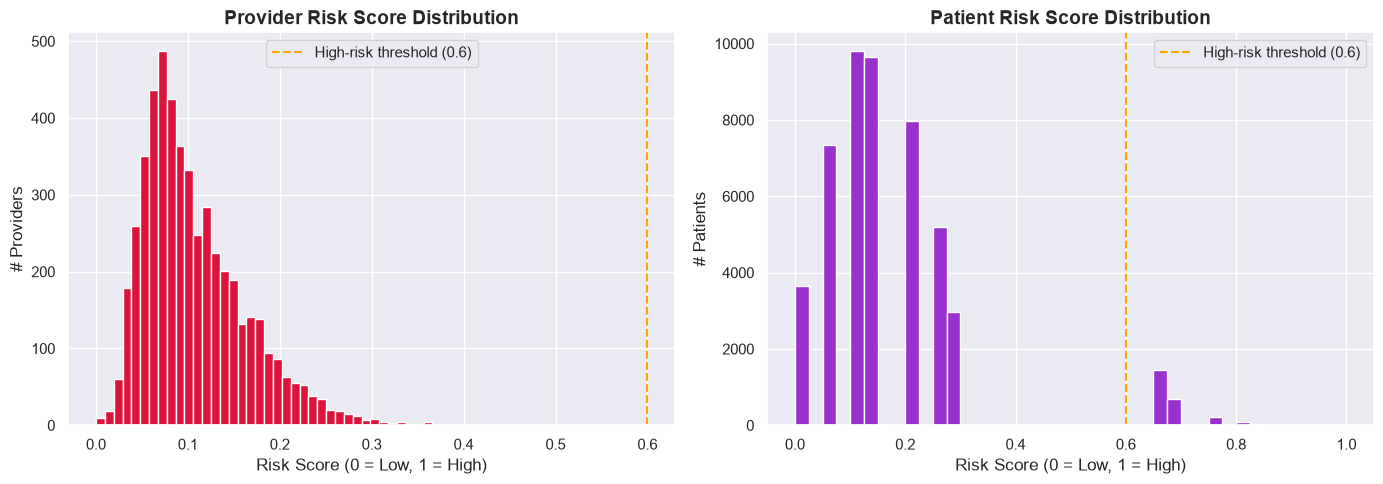


🚨 High-Risk Providers (score ≥ 0.6) : 0
🚨 High-Risk Patients  (score ≥ 0.6) : 2,506


In [ ]:
# ── Risk Score Visualisations ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(provider_feats['provider_risk_score'], bins=40,
             color='crimson', edgecolor='white')
axes[0].set_title("Provider Risk Score Distribution")
axes[0].set_xlabel("Risk Score (0 = Low, 1 = High)")
axes[0].set_ylabel("# Providers")
axes[0].axvline(0.6, color='orange', linestyle='--', label='High-risk threshold (0.6)')
axes[0].legend()

axes[1].hist(patient_feats['patient_risk_score'], bins=40,
             color='darkorchid', edgecolor='white')
axes[1].set_title("Patient Risk Score Distribution")
axes[1].set_xlabel("Risk Score (0 = Low, 1 = High)")
axes[1].set_ylabel("# Patients")
axes[1].axvline(0.6, color='orange', linestyle='--', label='High-risk threshold (0.6)')
axes[1].legend()

plt.tight_layout()
plt.savefig("..\\image\risk_score_distributions.png", dpi=100, bbox_inches='tight')
plt.show()

high_risk_providers = (provider_feats['provider_risk_score'] >= 0.6).sum()
high_risk_patients  = (patient_feats['patient_risk_score']  >= 0.6).sum()
print(f"\n🚨 High-Risk Providers (score ≥ 0.6) : {high_risk_providers:,}")
print(f"🚨 High-Risk Patients  (score ≥ 0.6) : {high_risk_patients:,}")


In [ ]:
# ── Top 20 Highest Risk Providers ─────────────
top_risk_providers = (
    provider_feats
    .merge(providers[['provider_id','name']], on='provider_id', how='left')
    .nlargest(20, 'provider_risk_score')
    [['name','specialty','provider_risk_score',
      'provider_rejection_rate','claim_freq_z','billing_z','dup_rate']]
)
print("Top 20 Highest-Risk Providers:")
display(top_risk_providers.round(4))


Top 20 Highest-Risk Providers:


,name,specialty,provider_risk_score,provider_rejection_rate,claim_freq_z,billing_z,dup_rate
1422,"Walker, Hunter and White",Orthopedic,0.3853,0.1875,0.5864,0.1156,0.0
4194,"Rojas, Rogers and Martinez",Oncologist,0.3658,0.1500,0.5028,0.2533,0.0
3347,Johnson Group,Dermatologist,0.3623,0.3500,0.5029,0.0000,0.0
4716,Deleon Ltd,General Practitioner,0.3616,0.2419,0.5648,0.0000,0.0
949,"Smith, Rosales and Collins",Dermatologist,0.3593,0.2203,0.4778,0.1939,0.0
4178,"Smith, Clark and Banks",Cardiologist,0.3510,0.2034,0.4677,0.2021,0.0
693,Scott Ltd,Cardiologist,0.3462,0.2759,0.4428,0.1471,0.0
2781,Morris-Daniel,Orthopedic,0.3443,0.3167,0.4872,0.0000,0.0
1867,"Sutton, Moore and Green",Oncologist,0.3369,0.1273,0.3775,0.4205,0.0
1703,"Hernandez, Small and Fitzpatrick",Oncologist,0.3359,0.3051,0.4777,0.0000,0.0


---
## 11. Export Final Datasets <a id='11'></a>


In [ ]:
# ── Assemble feature-engineered master table ──
feature_df = (
    master_df
    .merge(patient_feats[[
        'patient_id','claims_per_patient','avg_claim_patient',
        'patient_lifetime_value','days_since_last_claim',
        'unique_providers_visited','patient_shopping_flag','patient_risk_score'
    ]], on='patient_id', how='left')
    .merge(provider_feats[[
        'provider_id','provider_claim_count','provider_avg_claim',
        'provider_rejection_rate','provider_vs_specialty_ratio',
        'billing_z','claim_freq_z','dup_rate','provider_risk_score'
    ]], on='provider_id', how='left')
    .merge(payment_feats, on='claim_id', how='left')
)

print(f"feature_engineered.csv shape: {feature_df.shape}")
feature_df.head(3)


feature_engineered.csv shape: (200000, 43)


,claim_id,patient_id,provider_id,claim_date,claim_amount,status,age,gender,patient_state,provider_name,...,provider_rejection_rate,provider_vs_specialty_ratio,billing_z,claim_freq_z,dup_rate,provider_risk_score,payment_ratio_y,settlement_days_y,underpayment_flag,overpayment_flag
0,1,23406,4385,2024-01-06,27537.0,Rejected,67,Other,South Dakota,Campos-Howe,...,0.166667,1.0488,0.073955,0.0,0.0,0.0686,0.954684,-213.0,0.0,0.0
1,2,21811,4979,2024-01-27,40137.0,Approved,24,Female,Nebraska,Reese LLC,...,0.203704,0.9385,0.000000,0.352502,0.0,0.2415,0.982233,55.0,0.0,0.0
2,3,13518,242,2024-04-03,20860.0,Approved,83,Male,Hawaii,Russo LLC,...,0.190476,0.9431,0.000000,0.051946,0.0,0.0837,0.856151,191.0,0.0,0.0


In [ ]:
# ── Save outputs ──────────────────────────────
master_df.to_csv("..\\cleaned_data\master_cleaned.csv", index=False)
feature_df.to_csv("..\\cleaned_data\ feature_engineered.csv", index=False)
provider_feats.to_csv("..\\cleaned_data\provider_risk_scores.csv", index=False)
patient_feats.to_csv("..\\cleaned_data\patient_risk_scores.csv", index=False)

print("✅ Exports complete:")
print(f"   master_cleaned.csv       — {master_df.shape[0]:,} rows × {master_df.shape[1]} cols")
print(f"   feature_engineered.csv   — {feature_df.shape[0]:,} rows × {feature_df.shape[1]} cols")
print(f"   provider_risk_scores.csv — {provider_feats.shape[0]:,} rows")
print(f"   patient_risk_scores.csv  — {patient_feats.shape[0]:,} rows")
print()
print("🎯 Next Steps:")
print("   • Use feature_engineered.csv as input to Isolation Forest / XGBoost fraud model")
print("   • provider_risk_score  →  target encode or use as a feature")
print("   • Explainable AI (SHAP) on top flagged providers to audit decisions")
print("   • LLM narrative layer: 'Explain why provider X is high-risk in plain English'")


✅ Exports complete:
   master_cleaned.csv       — 200,000 rows × 24 cols
   feature_engineered.csv   — 200,000 rows × 43 cols
   provider_risk_scores.csv — 5,000 rows
   patient_risk_scores.csv  — 49,096 rows

🎯 Next Steps:
   • Use feature_engineered.csv as input to Isolation Forest / XGBoost fraud model
   • provider_risk_score  →  target encode or use as a feature
   • Explainable AI (SHAP) on top flagged providers to audit decisions
   • LLM narrative layer: 'Explain why provider X is high-risk in plain English'
